In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay,classification_report
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score




In [3]:
df=pd.read_csv("train.csv")

In [4]:
df.iloc[0].to_dict()

{'id': 0,
 'gender': 'Male',
 'SeniorCitizen': 0,
 'Partner': 'Yes',
 'Dependents': 'Yes',
 'tenure': 29,
 'PhoneService': 'Yes',
 'MultipleLines': 'No',
 'InternetService': 'DSL',
 'OnlineSecurity': 'Yes',
 'OnlineBackup': 'No',
 'DeviceProtection': 'Yes',
 'TechSupport': 'Yes',
 'StreamingTV': 'No',
 'StreamingMovies': 'No',
 'Contract': 'One year',
 'PaperlessBilling': 'Yes',
 'PaymentMethod': 'Mailed check',
 'MonthlyCharges': 60.1,
 'TotalCharges': 1653.85,
 'Churn': 'No'}

EDA

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [48]:
# SUMMARY OF THE DATAFRAME

df.head(3)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4,5841.35,No


In [49]:
#number of customers based on conracts joined

df["Contract"].value_counts().to_frame()

,count
Contract,
Month-to-month,298918
Two year,186943
One year,108333


In [50]:
# DESCRIPTIVE STATISTICS FOR NUMARICAL COLUMNS

num_col=["MonthlyCharges","TotalCharges","tenure"]
df[num_col].describe().round(2)

,MonthlyCharges,TotalCharges,tenure
count,594194.00,594194.00,594194.00
mean,65.87,2494.38,36.58
std,31.07,2353.92,25.06
min,18.25,18.80,1.00
25%,29.90,639.65,12.00
50%,74.10,1433.65,35.00
75%,90.80,4263.80,62.00
max,118.75,8684.80,72.00


                           MonthlyCharges
PaymentMethod                            
Bank transfer (automatic)           66.56
Credit card (automatic)             66.42
Electronic check                    81.28
Mailed check                        37.77


Text(0.5, 0, 'Amount in Rand')

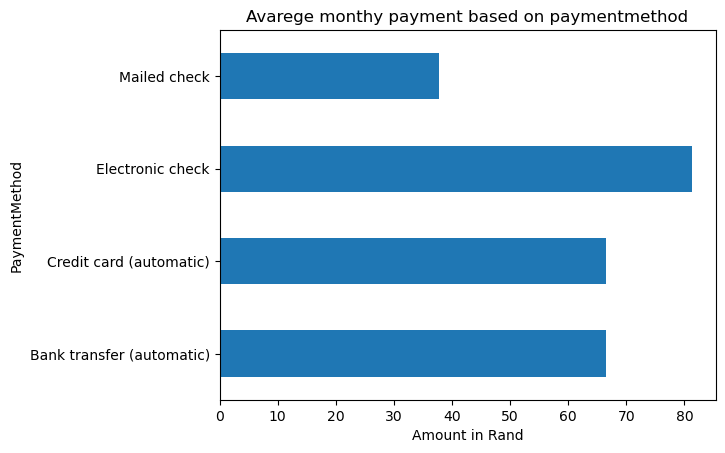

In [51]:
#  Avarege monthly chargers based on payment method

charges=df.groupby("PaymentMethod")["MonthlyCharges"].mean().round(2).to_frame()
print(charges)
df.groupby("PaymentMethod")["MonthlyCharges"].mean().round(2).plot(kind='barh')

plt.title("Avarege monthy payment based on paymentmethod")
plt.xlabel("Amount in Rand")


                           TotalCharges
PaymentMethod                          
Bank transfer (automatic)       3528.01
Credit card (automatic)         3554.72
Electronic check                2090.13
Mailed check                    1038.69


Text(0.5, 0, 'Amount in Rand')

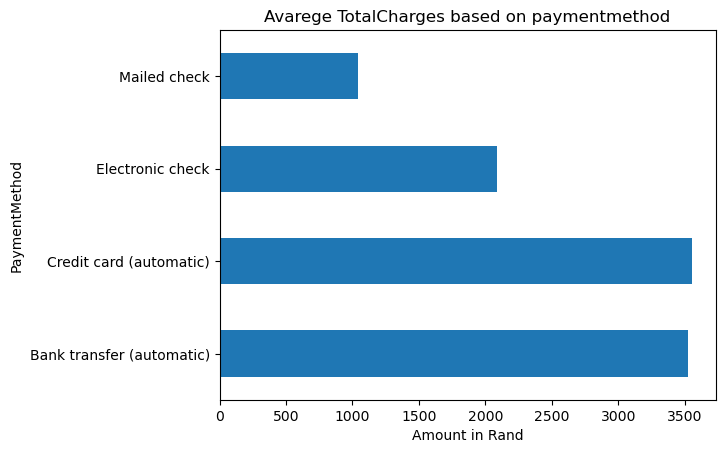

In [52]:
charges=df.groupby("PaymentMethod")["TotalCharges"].mean().round(2).to_frame()
print(charges)
df.groupby("PaymentMethod")["TotalCharges"].mean().round(2).plot(kind='barh')

plt.title("Avarege TotalCharges based on paymentmethod")
plt.xlabel("Amount in Rand")

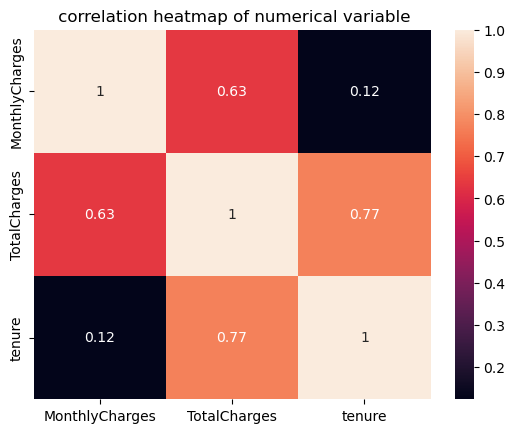

In [53]:
# checking correlation on numerical columns

sns.heatmap(df[["MonthlyCharges","TotalCharges","tenure"]].corr(),annot=True);
plt.title(" correlation heatmap of numerical variable");

DATA PREPROCESSING


In [54]:
def preprocess (df):
    binary_columns=["PaperlessBilling","PhoneService","Dependents","Partner"]
    for i in binary_columns:
        df[i]=df[i].map({"Yes":1,"No":0})
        
    df["gender"]=df["gender"].map({"Female":0,"Male":1})
    
    cat_col= list(df.select_dtypes("object").columns)
    num_col=["MonthlyCharges","TotalCharges","tenure"]
# initiating the pre processor

    preprocessing=ColumnTransformer(transformers=[
    ("cat",OneHotEncoder(drop="first",sparse_output=False),cat_col),
    ("num",StandardScaler(),num_col)
    ],remainder="passthrough")

# fit and transform
    encoded=preprocessing.fit_transform(df)

# new df
    new_cols=preprocessing.get_feature_names_out()
    final_df=pd.DataFrame(encoded,columns=new_cols)
    final_df.columns=[c.split("_")[-1]for c in final_df.columns]
    final_df.drop(columns=["id"],inplace=True)
    return final_df
    

MODEL DEVELOPMENT


In [55]:
# LET X REPRESENT  FEATURE MATRIX AND y REPRESENT  target variable

X=final_df.drop(columns=["id","Churn"])

In [56]:
# target variable analsis

y=final_df["Churn"]
y.value_counts(normalize=True)



Churn
0.0    0.774792
1.0    0.225208
Name: proportion, dtype: float64

In [57]:
pca = PCA(n_components=0.95)  # keep 95% variance
X_pca = pca.fit_transform(X)


In [58]:
len(X_pca)

594194

In [59]:
# creating training and testing dataset

X_train,X_test,y_train,y_test=train_test_split(X_pca,y,random_state=42,test_size=0.2)

BASELINE MODEL

In [ ]:
#Baseline model

lr=DecisionTreeClassifier(max_depth=25)
lr.fit(X_train,y_train)

TRAINING THE MODEL RandomForestClassifier

In [107]:
#TRAINING THE MODEL
rf = RandomForestClassifier( random_state=42, class_weight='balanced',n_jobs=-1,n_estimators=199,max_depth=7,min_samples_split=4,min_samples_leaf=4)
rf.fit(X_pca, y)
# feature importances
importances = rf.feature_importances_


In [108]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
top_features = indices[:10]

# Select top features from train/test
X_train_selected = X_train[:, top_features]
X_test_selected  = X_test[:, top_features]

# Train new RF on selected features
rf_selected = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    n_estimators=199,
    max_depth=7,
    min_samples_split=4,min_samples_leaf=4
)
rf_selected.fit(X_train_selected, y_train)

# Predict
y_pred = rf_selected.predict(X_test_selected)

# Evaluate
print("Precision:", precision_score(y_test, y_pred, pos_label=1))
print("Recall:", recall_score(y_test, y_pred, pos_label=1))
print("F1-score:", f1_score(y_test, y_pred, pos_label=1))
print(classification_report(y_test, y_pred))


Precision: 0.5522580041628663
Recall: 0.8777133511745465
F1-score: 0.6779495571537258
              precision    recall  f1-score   support

         0.0       0.96      0.79      0.87     91935
         1.0       0.55      0.88      0.68     26904

    accuracy                           0.81    118839
   macro avg       0.75      0.83      0.77    118839
weighted avg       0.87      0.81      0.82    118839



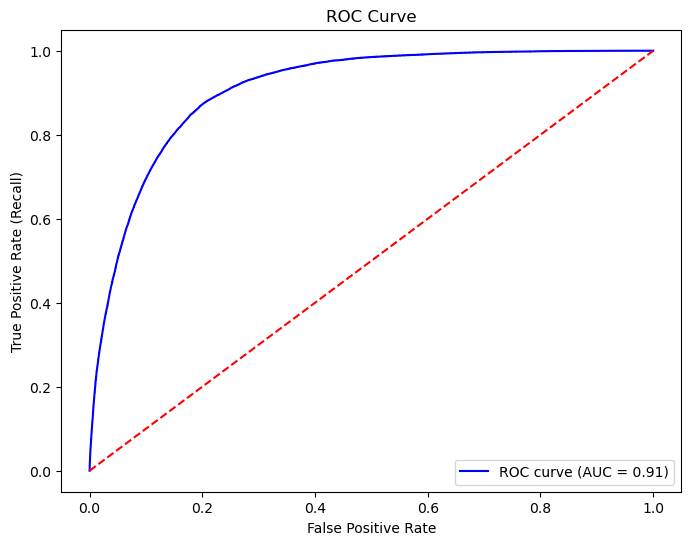

In [109]:

# Fit your model

y_pred_proba = rf.predict_proba(X_test)[:,1]  # probabilities for class 1 (churn)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label=1)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [68]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
top_features = indices[:10]

# Select top features from train/test
X_train_selected = X_train[:, top_features]
X_test_selected  = X_test[:, top_features]

# Train new RF on selected features
lr.fit(X_train_selected, y_train)

# Predict
y_pred = rf_selected.predict(X_test_selected)

# Evaluate
print("Precision:", precision_score(y_test, y_pred, pos_label=1))
print("Recall:", recall_score(y_test, y_pred, pos_label=1))
print("F1-score:", f1_score(y_test, y_pred, pos_label=1))
print(classification_report(y_test, y_pred))


Precision: 0.5492271662763466
Recall: 0.8716919417187036
F1-score: 0.6738693178552957
              precision    recall  f1-score   support

         0.0       0.95      0.79      0.86     91935
         1.0       0.55      0.87      0.67     26904

    accuracy                           0.81    118839
   macro avg       0.75      0.83      0.77    118839
weighted avg       0.86      0.81      0.82    118839



TRANING XGB

In [114]:
from xgboost import XGBClassifier
#Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'scale_pos_weight': 1, 'subsample': 0.8}

xgb = XGBClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=47,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=1.0,
    scale_pos_weight=1,   # adjust if classes are imbalanced
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric="logloss",
)
xgb.fit(X_train, y_train)

# Get feature importances
importances = xgb.feature_importances_
indices = np.argsort(importances)[::-1]
top_features = indices[:10]

# Select top features
X_train_selected = X_train[:, top_features]
X_test_selected  = X_test[:, top_features]

# Train new XGBoost model on selected features
xgb_selected = XGBClassifier(
    random_state=42,
    n_estimators=250,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric="logloss"
)
xgb_selected.fit(X_train_selected, y_train)

# Predict
y_pred = xgb_selected.predict(X_test_selected)

# Evaluate
print("Precision:", precision_score(y_test, y_pred, pos_label=1))
print("Recall:", recall_score(y_test, y_pred, pos_label=1))
print("F1-score:", f1_score(y_test, y_pred, pos_label=1))
print(classification_report(y_test, y_pred))


C:\Users\precious\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:21:36] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\precious\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:55:25] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Precision: 0.7052846374880273
Recall: 0.6294974724947963
F1-score: 0.6652395074336666
              precision    recall  f1-score   support

         0.0       0.89      0.92      0.91     91935
         1.0       0.71      0.63      0.67     26904

    accuracy                           0.86    118839
   macro avg       0.80      0.78      0.79    118839
weighted avg       0.85      0.86      0.85    118839



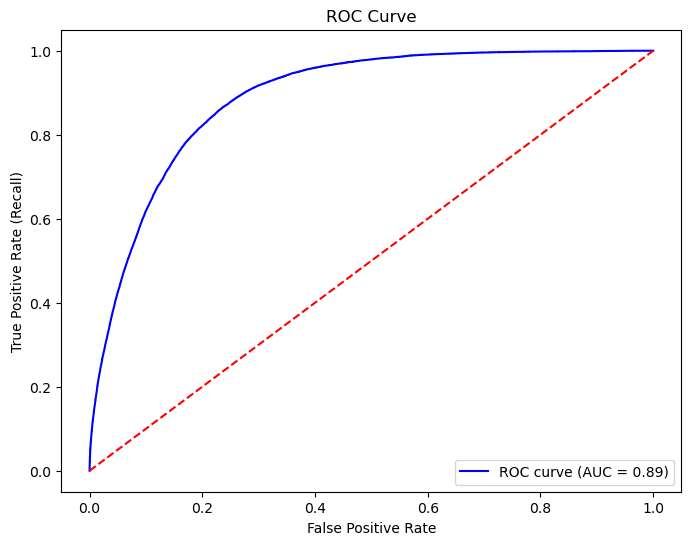

In [115]:
#GETTING THE ROU CURVE

y_pred_proba = xgb.predict_proba(X_test)[:,1]  # probabilities for class 1 (churn)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label=1)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

HYPERTUNNING MY MODELS FOR BEST RESULTS


In [84]:
# Random Search

param_dist = {
    'n_estimators': randint(50, 200),       # number of trees
    'max_depth': randint(2, 10),            # depth of trees
    'min_samples_split': randint(2, 10),    # min samples to split
    'min_samples_leaf': randint(1, 5)       # min samples per leaf
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,                # number of random combinations to try
    cv=5,                     # 5-fold cross-validation
    scoring='f1',
    random_state=42,
    n_jobs=-1                 # use all cores
)

# Fit
random_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:", random_search.best_params_)
print("Best CV score:", random_search.best_score_)

# Evaluate on test set
print("Test set accuracy:", random_search.score(X_test, y_test))


Best parameters: {'max_depth': 9, 'min_samples_leaf': 4, 'min_samples_split': 4, 'n_estimators': 199}
Best CV score: 0.6766501625210513
Test set accuracy: 0.6809613435644998


TUNNING XGB

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Base model
xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss",
    n_jobs=-1
)

# Parameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "scale_pos_weight": [1, int(len(y_train[y_train==0]) / len(y_train[y_train==1]))]
}

# Grid search
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="roc_auc",   # or "f1", depending on your goal
    cv=3,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best ROC AUC:", grid_search.best_score_)

NOW GETTING PROPABILITIES FROM MY TEST FILE AND  SAVING THEM AS CSV


In [ ]:
pca = PCA(n_components=0.95)  # keep 95% variance
X_pca = pca.fit_transform(check)

In [74]:
#TEST DATA
test=pd.read_csv("test.csv")

In [ ]:
X_test_pca = pca.transform(check) 

In [75]:
check=preprocess(test)

FOR RANDOM ROREST 

In [ ]:
# Fit RF on PCA-transformed training data
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1,
    n_estimators=20,
    max_depth=3
)
rf.fit(X_pca, y)

# Get feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
top_features = indices[:10]

# Select top features
X_train_selected = X_pca[:, top_features]
X_test_selected = check_pca[:, top_features]

# Train new RF on selected features
rf_selected = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    n_estimators=20,
    max_depth=3
)
rf_selected.fit(X_train_selected, y)

# Predict
y_pred = rf_selected.predict(X_test_selected)

# Evaluate
"""
print("Precision:", precision_score(y_test, y_pred, pos_label=1))
print("Recall:", recall_score(y_test, y_pred, pos_label=1))
print("F1-score:", f1_score(y_test, y_pred, pos_label=1))
print(classification_report(y_test, y_pred))
"""


In [ ]:
y_pred_proba = rf_selected.predict_proba(check_pca[:, top_features])[:, 1]

# Build the submission DataFrame
submission = pd.DataFrame({
    "id": test["id"],       # keep the original IDs
    "Churn": y_pred_proba   # probability of churn
})

# Save to CSV
submission.to_csv("submission.csv", index=False)


FOR XGB  MODEL


In [76]:
# Fit RF on PCA-transformed training data
xgb= XGBClassifier(
    random_state=42,
    n_estimators=250,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(X_pca, y)

# Get feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
top_features = indices[:10]

# Select top features
X_train_selected = X_pca[:, top_features]
X_test_selected = check_pca[:, top_features]

# Train new RF on selected features
xgb_selected = XGBClassifier(
    random_state=42,
    n_estimators=250,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric="logloss"
)
xgb_selected.fit(X_train_selected, y)

# Predict
y_pred = rf_selected.predict(X_test_selected)




C:\Users\precious\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:44:46] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\precious\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:45:57] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


'\nprint("Precision:", precision_score(y_test, y_pred, pos_label=1))\nprint("Recall:", recall_score(y_test, y_pred, pos_label=1))\nprint("F1-score:", f1_score(y_test, y_pred, pos_label=1))\nprint(classification_report(y_test, y_pred))\n'

In [77]:
y_pred_proba = rf_selected.predict_proba(check_pca[:, top_features])[:, 1]

# Build the submission DataFrame
submission = pd.DataFrame({
    "id": test["id"],       # keep the original IDs
    "Churn": y_pred_proba   # probability of churn
})

# Save to CSV
submission.to_csv("xgb_submission.csv", index=False)


CREATING A PIPELINE

In [3]:
from sklearn.pipeline import Pipeline
